# Visualize Predictor Performance

This notebook runs the trained MeasurementEmbedder + Predictor on a subset
of the generated dataset and produces scatter plots of predicted vs true
packet-loss and delay (ms). It is intended as a lightweight visualization
tool to inspect predictor quality.


In [6]:
import torch
tensor_1d = torch.zeros(5)
print("1D Tensor:", tensor_1d)

t = int(tensor_1d[0].item())
print(f"t = {t}, type = {type(t)}")

1D Tensor: tensor([0., 0., 0., 0., 0.])
t = 0, type = <class 'int'>


c:\Users\chris\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Collected 8850 predictions


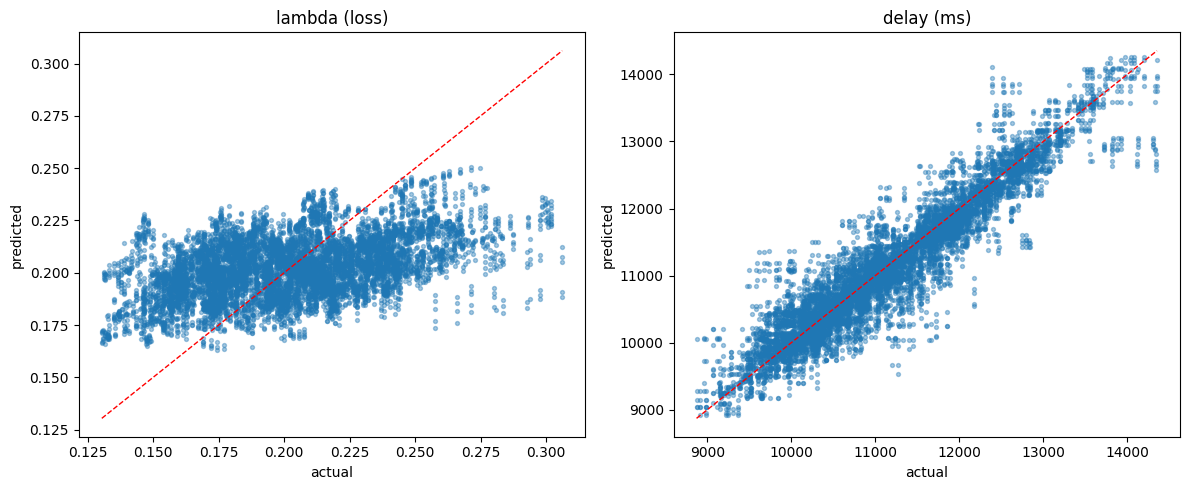

In [1]:
import sys, os
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathEncoder import GATv2Encoder, overlay_encodings
from torch_geometric.data import Data

sys.path.insert(0, os.path.abspath('.'))

from trainer.dataset import PredictorDataset
from meas_predictor import MeasurementEmbedder, Predictor

dataset_path = 'data/predictor_dataset.pt'
model_path = 'models/predictor_models.pth'

dataset = PredictorDataset(dataset_path)

encoder = GATv2Encoder(in_dim=8, hidden_dim=32, out_dim=32, edge_dim=1)
embedder = MeasurementEmbedder(h_dim=32, hidden_dim=32, out_dim=32)
predictor = Predictor(in_dim=32 + 32 + 1, hidden_dim=32)

ckpt = torch.load(model_path, map_location='cpu')
if 'encoder_state' in ckpt and 'embedder_state' in ckpt and 'predictor_state' in ckpt:
    encoder.load_state_dict(ckpt['encoder_state'])
    embedder.load_state_dict(ckpt['embedder_state'])
    predictor.load_state_dict(ckpt['predictor_state'])
else:
    print('Checkpoint format not recognized; ensure models/predictor_models.pth was created by trainer.')

encoder.eval(); embedder.eval(); predictor.eval()

M = 5
Delta = 3
FIXED = {'t', 'x', 'edge_index', 'edge_attr', 'node_names', 'name_to_idx'}

preds = []
labels = []

lo = Delta - 1
hi = len(dataset) - M

with torch.no_grad():
    for t in range(lo, hi):
        curr_overlay = [{k: dataset[t][k]} for k in dataset[t] if k not in FIXED]

        # ---- build history (same as trainer) ----
        H_hist, Meas_hist, Elapsed = [], [], []
        for i in range(0, Delta):
            d = dataset[t - i]
            data = Data(x=d['x'], edge_index=d['edge_index'], edge_attr=d['edge_attr'],
                        node_names=d['node_names'], name_to_idx=d['name_to_idx'])
            hist_overlay = [{k: d[k]} for k in d if k not in FIXED]
            h_hist = overlay_encodings(data, hist_overlay, encoder, device="cpu")
            for ovl_dict in hist_overlay:
                oid, ovl = next(iter(ovl_dict.items()))
                H_hist.append(h_hist[oid])
                Meas_hist.append(torch.tensor(ovl['meas'], dtype=torch.float))
                Elapsed.append(float(i))
        H_hist = torch.stack(H_hist)
        Meas_hist = torch.stack(Meas_hist)
        Elapsed = torch.tensor(Elapsed).unsqueeze(1)

        # ---- predict future steps (same as trainer) ----
        for m in range(1, M + 1):
            d = dataset[t + m]
            data = Data(x=d['x'], edge_index=d['edge_index'], edge_attr=d['edge_attr'],
                        node_names=d['node_names'], name_to_idx=d['name_to_idx'])
            h_pred = overlay_encodings(data, curr_overlay, encoder, device="cpu")
            for ovl in curr_overlay:
                oid, _ = next(iter(ovl.items()))
                g = embedder(h_pred[oid], H_hist, Meas_hist, Elapsed)
                H = torch.cat([h_pred[oid], g, torch.tensor([float(m)])], dim=0).unsqueeze(0)
                out = predictor(H).squeeze(0).numpy()
                if oid in d:
                    tgt = np.array(d[oid]['meas'], dtype=np.float32)
                    preds.append(out)
                    labels.append(tgt)

preds = np.array(preds)
labels = np.array(labels)
print(f'Collected {len(preds)} predictions')

# ---- plot: predicted vs actual, one panel per metric ----
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
names = ['lambda (loss)', 'delay (ms)']
for j, ax in enumerate(axes):
    ax.scatter(labels[:, j], preds[:, j], s=8, alpha=0.4)
    lim = [min(labels[:, j].min(), preds[:, j].min()),
           max(labels[:, j].max(), preds[:, j].max())]
    ax.plot(lim, lim, 'r--', linewidth=1)          # perfect-prediction diagonal
    ax.set_xlabel('actual'); ax.set_ylabel('predicted')
    ax.set_title(names[j])
plt.tight_layout()
plt.show()

NameError: name 'labels' is not defined

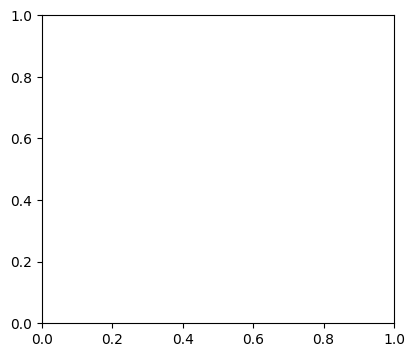

In [2]:
# Scatter plots: predicted vs true for loss and delay
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.scatter(labels[:,0], preds[:,0], s=8)
plt.xlabel('True packet-loss (fraction)')
plt.ylabel('Predicted packet-loss')
plt.title('Packet-loss: true vs predicted')
mn, mx = min(labels[:,0].min(), preds[:,0].min()), max(labels[:,0].max(), preds[:,0].max())
plt.plot([mn,mx],[mn,mx],'r--')

plt.subplot(1,2,2)
plt.scatter(labels[:,1], preds[:,1], s=8)
plt.xlabel('True delay (ms)')
plt.ylabel('Predicted delay (ms)')
plt.title('Delay (ms): true vs predicted')
mn, mx = min(labels[:,1].min(), preds[:,1].min()), max(labels[:,1].max(), preds[:,1].max())
plt.plot([mn,mx],[mn,mx],'r--')
plt.tight_layout()
plt.show()
